In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [8]:
df=pd.read_csv('tr_server_data.csv',header=None)
df.head()

,0,1
0,13.047,14.741
1,13.409,13.763
2,14.196,15.853
3,14.915,16.174
4,13.577,14.043


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       307 non-null    float64
 1   1       307 non-null    float64
dtypes: float64(2)
memory usage: 4.9 KB


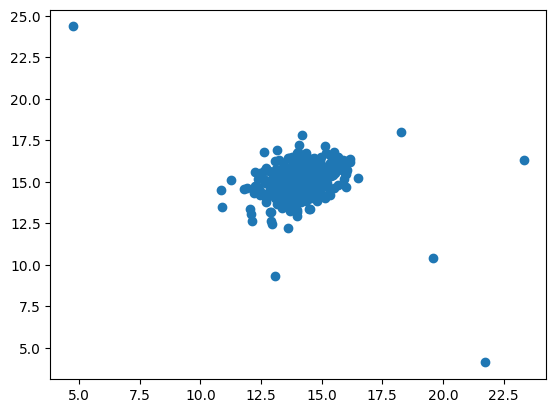

In [10]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])

In [11]:
from sklearn.ensemble import IsolationForest

In [12]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_samples": [0.5, 0.75, 1.0],
    "contamination": [0.01, 0.05, 0.1,0.2,0.3]
}

for params in ParameterGrid(param_grid):
    model = IsolationForest(**params, random_state=42)
    model.fit(df)
    predictions = model.predict(df)

In [13]:
scores = model.decision_function(df)

print(scores.min())
print(scores.max())

-0.45626211872554995
0.05940095655190464


In [18]:
print("Anomalies:", sum(predictions == -1))
print("Normal:", sum(predictions == 1))

Anomalies: 92
Normal: 215


In [14]:
predictions

array([ 1,  1,  1,  1,  1, -1,  1, -1, -1,  1, -1,  1,  1,  1, -1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1, -1,  1,
       -1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1,  1,  1,  1, -1,  1,
        1,  1,  1,  1, -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,
       -1, -1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1, -1, -1,  1,
        1, -1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,
       -1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1, -1, -1,  1,  1

In [15]:
index = np.where(predictions < 0)
index

(array([  5,   7,   8,  10,  14,  19,  22,  25,  30,  34,  36,  46,  62,
         63,  64,  66,  68,  69,  71,  73,  78,  81,  93,  95,  96, 100,
        106, 108, 109, 111, 113, 114, 115, 117, 119, 120, 124, 128, 131,
        134, 142, 143, 145, 147, 150, 151, 154, 161, 162, 165, 168, 170,
        172, 174, 179, 182, 187, 190, 191, 199, 200, 207, 213, 218, 222,
        223, 226, 228, 231, 239, 240, 241, 247, 249, 251, 253, 256, 261,
        270, 275, 276, 277, 279, 281, 299, 300, 301, 302, 303, 304, 305,
        306], dtype=int64),)

In [16]:
x=df.values

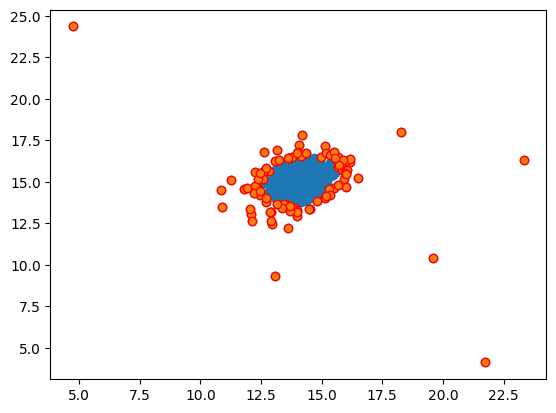

In [17]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.scatter(x[index, 0], x[index, 1], edgecolors='r')

In [20]:
scores[:10]

array([ 0.03445987,  0.00162252,  0.03860472,  0.01419669,  0.02782105,
       -0.01172986,  0.00538544, -0.00562114, -0.05649229,  0.00562187])

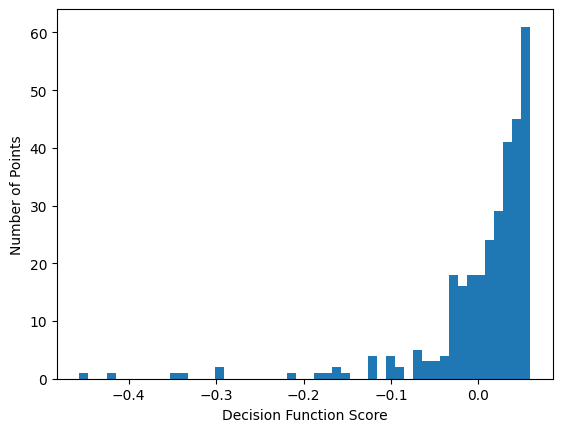

In [21]:
import matplotlib.pyplot as plt

plt.hist(scores, bins=50)
plt.xlabel("Decision Function Score")
plt.ylabel("Number of Points")
plt.show()

In [24]:
Anomalies=sum(predictions == -1)
Normal=sum(predictions == 1)
print(Anomalies,Normal)
model_anomalise_calculation=Anomalies/(Anomalies+Normal)

print("percentage of points classified as anomalies classified by model", model_anomalise_calculation*100)

92 215
percentage of points classified as anomalies classified by model 29.967426710097723


In [25]:
print(model.contamination)

0.3
